In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATA_ROOT = '../../data'

In [3]:
PCC_200_randn_all = pd.read_csv(f'{DATA_ROOT}/5000_samples_results.csv', index_col= 0, header = 0)
PCC_200_randn_all

,train_loss,test_loss,stopped_early,stopped_epoch,in_features
A2M,0.426968,0.420830,1,12,1075
A2ML1,0.129107,0.129309,1,18,1075
A4GALT,0.173555,0.162414,1,9,1075
AAAS,0.092789,0.100891,1,8,1075
AACS,0.089489,0.104314,1,9,1075
...,...,...,...,...,...
ZYG11A,0.178360,0.184094,1,8,1075
ZYG11B,0.082030,0.083792,1,9,1075
ZYX,0.152492,0.167716,1,9,1075
ZZEF1,0.052421,0.063253,1,9,1075


In [4]:
PCC_200_randn_all['Train'] = 1 - PCC_200_randn_all['train_loss']
PCC_200_randn_all['Test'] = 1 - PCC_200_randn_all['test_loss']

In [5]:
PCC_200_randn_all

,train_loss,test_loss,stopped_early,stopped_epoch,in_features,Train,Test
A2M,0.426968,0.420830,1,12,1075,0.573032,0.579170
A2ML1,0.129107,0.129309,1,18,1075,0.870893,0.870691
A4GALT,0.173555,0.162414,1,9,1075,0.826445,0.837586
AAAS,0.092789,0.100891,1,8,1075,0.907211,0.899109
AACS,0.089489,0.104314,1,9,1075,0.910511,0.895686
...,...,...,...,...,...,...,...
ZYG11A,0.178360,0.184094,1,8,1075,0.821640,0.815906
ZYG11B,0.082030,0.083792,1,9,1075,0.917970,0.916208
ZYX,0.152492,0.167716,1,9,1075,0.847508,0.832284
ZZEF1,0.052421,0.063253,1,9,1075,0.947579,0.936747


In [5]:
External_PCC_200_randn_all = pd.read_csv(f'./data/external_PEARSONS_200_randn_all.csv', index_col=0)
#remove models that did not evaluate
External_PCC_200_randn_all = External_PCC_200_randn_all[~External_PCC_200_randn_all['external_set_score'].isna()]
External_PCC_200_randn_all.columns = ['External PCC']
External_PCC_200_randn_all['External PCC'] = 1 - External_PCC_200_randn_all['External PCC']

KeyError: 'external_set_score'

In [28]:
External_PCC_200_randn_all['External PCC'].describe()

count    2873.000000
mean        0.581899
std         0.276548
min        -0.236299
25%         0.401187
50%         0.666663
75%         0.803614
max         0.961449
Name: External PCC, dtype: float64

<Axes: >

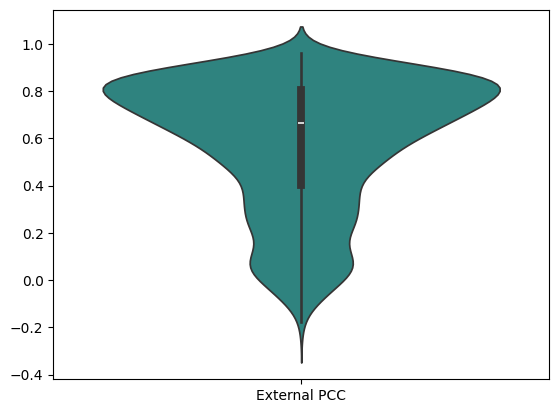

In [29]:
sns.violinplot(data = External_PCC_200_randn_all, palette = 'viridis')


In [5]:
np.sum(PCC_200_randn_all['stopped_early'])

np.float64(10.0)

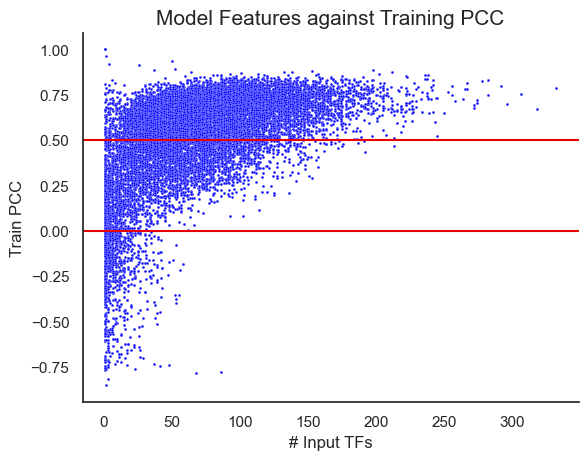

In [ ]:
TPM_res.loc[TPM_res['test_score'] < 0.2, :].shape[0]

In [ ]:
#log_to_plot = pd.melt(logTPM_res)
TPM_to_plot = pd.melt(TPM_res)

In [ ]:
#create function make train test MSE violin plot
def loss_violin_plot(df, palette, title, figtitle):
    fig, ax = plt.subplots()
    ax = sns.violinplot(data = df, x = 'variable', y="value", hue = 'variable', palette=palette)
    ax.set_ylabel('MSE', fontsize = 15)
    ax.set_xlabel('Dataset', fontsize = 15)
    fig.canvas.draw()
    labels = [item.get_text() for item in ax.get_xticklabels()]
    labels[0], labels[1] = ['Training', 'Test']
    ax.set_xticklabels(['Training', 'Test'], fontsize = 10)
    fig.suptitle(title, fontsize = 20)
    plt.savefig(figtitle, dpi = 300)

/var/folders/31/nm2_1xn55zl20tj7l_p3rzb40000gn/T/ipykernel_8909/1421562481.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Training', 'Test'], fontsize = 10)


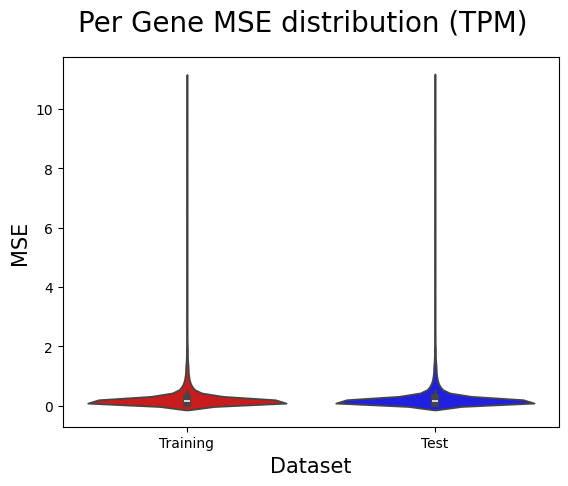

In [ ]:
loss_violin_plot(TPM_to_plot, palette=['#e60000', '#0000ff'], title ='Per Gene MSE distribution (TPM)', figtitle= 'figures/TPM_train_test')

# External dataset erorr scores

ValueError: Could not interpret value `log_external` for `y`. An entry with this name does not appear in `data`.

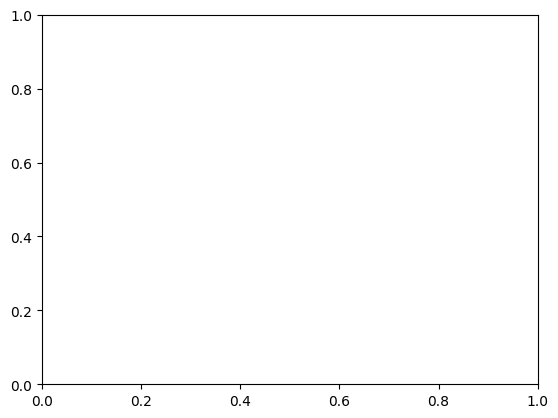

In [ ]:
fig, ax = plt.subplots(ncols=1)

sorted_results = merged_results.sort_values('in_features')
sns.scatterplot(data=sorted_results, x = 'train_score', y = 'log_external', legend=True, ax = ax, hue = 'in_features', palette='icefire', s=10)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
sns.despine()
ax.set_xlabel('Training Dataset MSE', fontsize = 10)
ax.set_ylabel('Log(External MSE + 1)', fontsize = 10)
fig.suptitle('Training vs External MSE and Model Size')
plt.savefig('figures/trainVSextVSModel', bbox_inches='tight')

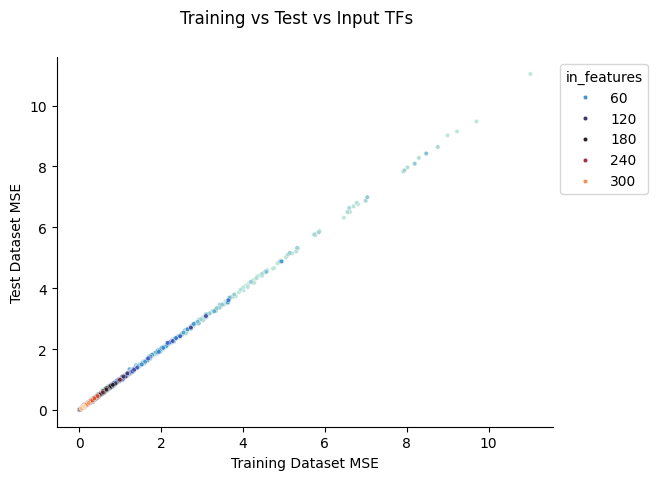

In [ ]:
fig, ax = plt.subplots(ncols=1)

sorted_results = merged_results.sort_values('in_features')
sns.scatterplot(data=sorted_results, x = 'train_score', y = 'test_score', legend=True, ax = ax, hue = 'in_features', palette='icefire', s=10)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
sns.despine()
ax.set_xlabel('Training Dataset MSE', fontsize = 10)
ax.set_ylabel('Test Dataset MSE', fontsize = 10)
fig.suptitle('Training vs Test vs Input TFs')
plt.savefig('figures/trainVsTestvsModel', bbox_inches='tight')

In [ ]:
external_res.loc[external_res['external_set_score'] < 1].shape

(13446, 2)

In [ ]:
external_res['log'] = np.log(external_res['external_set_score'] + 1)

/var/folders/31/nm2_1xn55zl20tj7l_p3rzb40000gn/T/ipykernel_88664/1795373650.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data = external_res, y="log", palette=['#e60000'])


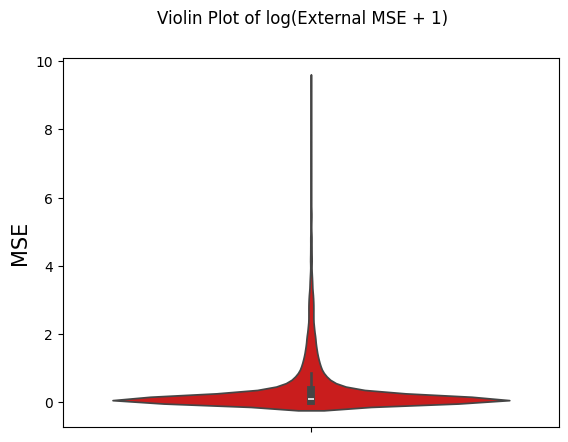

In [ ]:
fig, ax = plt.subplots()
ax = sns.violinplot(data = external_res, y="log", palette=['#e60000'])
ax.set_ylabel('MSE', fontsize = 15)
fig.suptitle('Violin Plot of log(External MSE + 1)')
plt.show()
#ax.set_xlabel('Dataset', fontsize = 15)
#fig.canvas.draw()
#labels = [item.get_text() for item in ax.get_xticklabels()]
#labels[0], labels[1] = ['Training', 'Test']
#ax.set_xticklabels(['Training', 'Test'], fontsize = 10)
#fig.suptitle(title, fontsize = 20)
#plt.savefig(figtitle, dpi = 300)

# PCC violin plots

In [22]:
#loading healthy results to create distribution of the absolute differences in PCC against subsampled results
healthy_results = pd.read_csv(f'{DATA_ROOT}/HEALTHY_results.csv', index_col= 0, header = 0)

healthy_results['Train'] = 1 - healthy_results['train_loss']
healthy_results['Test'] = 1 - healthy_results['test_loss']

In [23]:
healthy_results_to_plot = healthy_results[['Train', 'Test']].melt()
healthy_results_to_plot.columns = ['dataset', 'value']

In [30]:
#loading healthy results to create distribution of the absolute differences in PCC against subsampled results
subsamlped_results = pd.read_csv(f'{DATA_ROOT}/5000_samples_results.csv', index_col= 0, header = 0)

subsamlped_results['Train'] = 1 - subsamlped_results['train_loss']
subsamlped_results['Test'] = 1 - subsamlped_results['test_loss']

In [31]:
subsamlped_results_to_plot = subsamlped_results[['Train', 'Test']].melt()
subsamlped_results_to_plot.columns = ['dataset', 'value']

In [10]:
def create_pearsons_violin(results_df, y_col, title, file_title, figure_root = './figures', **kwargs):
    '''
    Taking a results df with two columns ['pearsons', 'dataset'] 
    Plots the pearsons values by dataset of origin as violin plots and saves figure with specified file_title at figure_root

    Parameters
    ---------------
    results_df : pandas dataframe
        dataframe containg the results to plot. Must contain a categorical column called dataset to serve as x axis categories
    y_col : string
        name of column in results df with statistic to make violin plot for 
    title : string
        title to display on plot
    file_title : string
        filename of saved figure
    figure_root : string
        path to directory in which to save the figure

    Returns
    --------------
    None
        Saves figure to desired location
    '''
    #store all plot formating arguments in dictionary - kwargs can then override
    plot_defaults = {'ylim':(-1, 1),
                     'palette':'viridis'}

    plot_kwargs = {**plot_defaults, **kwargs}

    #violin_plot_arguments = list(inspect.signature(sns.violinplot).parameters.keys())

    savepath = f'{figure_root}/{file_title}'

    fig, ax = plt.subplots()
    
    ax = sns.violinplot(data = results_df, x = 'dataset', y= y_col, hue = 'dataset', palette=plot_kwargs['palette'])

    if y_col == 'pearsons':
        ax.set_ylabel('Pearsons R', fontsize = 15)
    elif y_col == 'spearmans':
        ax.set_ylabel('Spearmans Rank', fontsize = 15)
    ax.set_xlabel('Dataset', fontsize = 15)
   
    plt.ylim(plot_kwargs['ylim'])
    fig.suptitle(title, fontsize = 20)
    plt.savefig(savepath, dpi = 300, bbox_inches = 'tight')

In [27]:
healthy_results_to_plot[healthy_results_to_plot['dataset'] == 'Test'].describe()

,value
count,15247.000000
mean,0.822586
std,0.106088
min,0.181156
25%,0.768599
50%,0.852387
75%,0.903887
max,0.961281


In [28]:
healthy_results_to_plot[healthy_results_to_plot['dataset'] == 'Test'].describe()

,value
count,15247.000000
mean,0.822586
std,0.106088
min,0.181156
25%,0.768599
50%,0.852387
75%,0.903887
max,0.961281


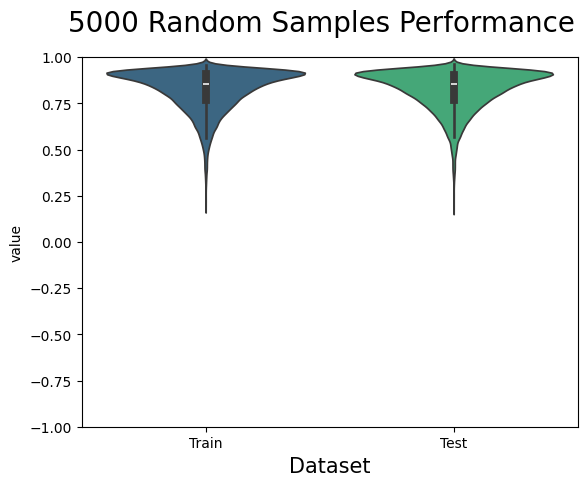

In [29]:
create_pearsons_violin(healthy_results_to_plot, y_col = 'value', title = '5000 Random Samples Performance', file_title = '5000_samples_violin')

In [34]:
subsamlped_results_to_plot

,dataset,value
0,Train,0.573032
1,Train,0.870893
2,Train,0.826445
3,Train,0.907211
4,Train,0.910511
...,...,...
30489,Test,0.815906
30490,Test,0.916208
30491,Test,0.832284
30492,Test,0.936747


In [32]:
healthy_results_to_plot

,dataset,value
0,Train,0.573145
1,Train,0.868809
2,Train,0.828602
3,Train,0.904867
4,Train,0.903674
...,...,...
30489,Test,0.837512
30490,Test,0.909711
30491,Test,0.854086
30492,Test,0.949234


In [36]:
healthy_sub_diff = healthy_results_to_plot
healthy_sub_diff['value'] = healthy_results_to_plot['value'] - subsamlped_results_to_plot['value']

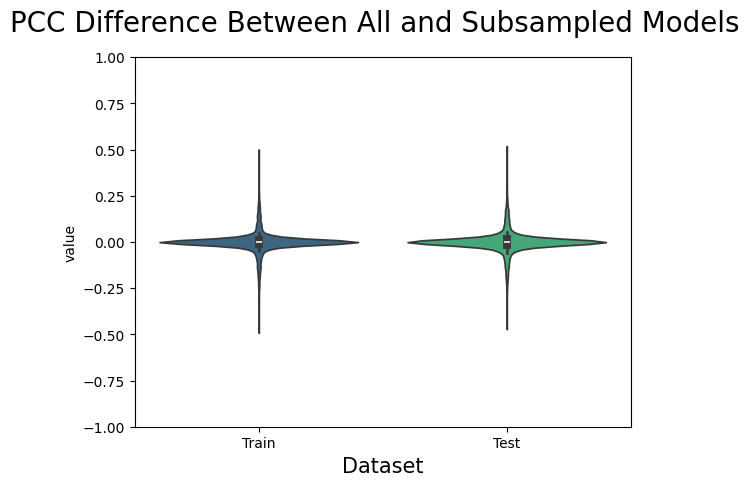

In [39]:
create_pearsons_violin(healthy_sub_diff, y_col ='value', title = 'PCC Difference Between All and Subsampled Models', file_title = '5000_vs_allSample_violin')